In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.integrate import odeint



In [3]:

def Kerr_system(N, Delta, K, Epsilon):
    a = destroy(N) 
    """
Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa 
        Lindbladiano: del sistema para un oscilador de Kerr 
        Expect_ops: np.array[] de los operadores que se requiera su valor esperado

     Hamiltoniano Kerr Oscillator de acuerdo al paper de Zhang2021:
         Detuning         (omega_d)
         No linealidad de Keer  (U)
         Squeezing              (G)
    """

    H = (
        - Delta*a.dag()*a               
        +  0.5*K* a.dag()*a.dag() *a*a       
        + 0.25*Epsilon* (a.dag()*a.dag() + a*a) 
        )
    
    return H
    
def Kerr_Diag(N, Delta, K, Epsilon, Jump_ops):
 
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa
        Eigenvalores del sistema.
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)
    L = liouvillian(H, Jump_ops)
    eigs = L.eigenenergies()

    return eigs

def Kerr_evo(N, Delta, K, Epsilon, Jump_ops, Expected_ops):
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    
    Regresa 
        Estados evolucionados para cada paso de tiempo
        Evolución del valor de expectacion de los Expect_ops
    '''
    t = linspace(0,10, 100) # 100 pasos de tiempo entre 0 - 10
    H = Kerr_system(N, Delta, K, Epsilon)

    init_rho = coherent(N, 1)
    evo = mesolve(H, init_rho, t, Jump_ops, Expect_ops)

    return evo 

    



In [4]:
# -----------------------Parametros-------------------------------
N = [20,40,60,80,100]              # dim Hilbert space
# Loss 
g = 1        
K_list = np.array(
    [1/15, 1/30, 1/60, 1/75]     # Interaction, Kerr NL
    )             
Delta = 0                         # Detuning 
epsi_list = np.linspace(0.01,2,100)    # Squeezing


"""
Calcular valor esperado de diferentes N para diferentes epsilon y diferentes K, en el ss
"""
# Pre-asignar array 3D para máxima eficiencia
n_2values = np.zeros((len(N), len(K_list), len(epsi_list)))

for i, d in enumerate(N):
    a = destroy(d)
    n = a.dag() * a
    salto = [np.sqrt(g) * a * a]
    
    for j, K in enumerate(K_list):
        print(f"d={d}, K={K:.4f}" + '\n')
        
        for k, e in enumerate(epsi_list):
            H = Kerr_system(d, Delta, K, e)
            rho_ss = steadystate(H, salto)    
            n_ss = expect(n, rho_ss)
            
            # Guardar directamente en el array
            n_2values[i, j, k] = n_ss
            
            # Imprimir solo primeros 5
            if k < 5:
                print(
                    rf"eps={e:.3f}, "
                    f"<n>={n_ss:.4f}, "
                    f"Tr={rho_ss.tr():.8f}, "
                    f"Tr^2={(rho_ss*rho_ss).tr():.8f}, "
                    f"minEig={np.min(rho_ss.eigenenergies()):.3e}"
                    )
        print('\n')
'''
Acceso fácil y eficiente:
    n_2values[0, 0, :]  # d=2 (índice 0), K=1/15 (índice 0)
    n_2values[1, 3, :]  # d=3 (índice 1), K=1/75 (índice 3)

Operaciones vectorizadas rápidas:
    np.mean(n_2values, axis=1)   Promedio sobre K para cada d
    np.max(n_2values, axis=2)   Máximo sobre epsilon
 '''       
print('-----------------------------------Finalizado------------------------------------')


d=20, K=0.0667

eps=0.010, <n>=0.0000, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.163e-16
eps=0.030, <n>=0.0002, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.498e-17
eps=0.050, <n>=0.0006, Tr=1.00000000, Tr^2=1.00000000, minEig=-3.540e-19
eps=0.070, <n>=0.0012, Tr=1.00000000, Tr^2=1.00000000, minEig=-1.167e-18
eps=0.090, <n>=0.0020, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.174e-19


d=20, K=0.0333

eps=0.010, <n>=0.0000, Tr=1.00000000, Tr^2=1.00000000, minEig=-3.679e-16
eps=0.030, <n>=0.0002, Tr=1.00000000, Tr^2=1.00000000, minEig=-1.013e-18
eps=0.050, <n>=0.0006, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.896e-18
eps=0.070, <n>=0.0012, Tr=1.00000000, Tr^2=1.00000000, minEig=-7.685e-21
eps=0.090, <n>=0.0020, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.261e-19


d=20, K=0.0167

eps=0.010, <n>=0.0000, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.863e-16
eps=0.030, <n>=0.0002, Tr=1.00000000, Tr^2=1.00000000, minEig=-8.526e-19
eps=0.050, <n>=0.0006, Tr=1.00000000, Tr^2=1.00000000, minEig=-3.524e-16

4


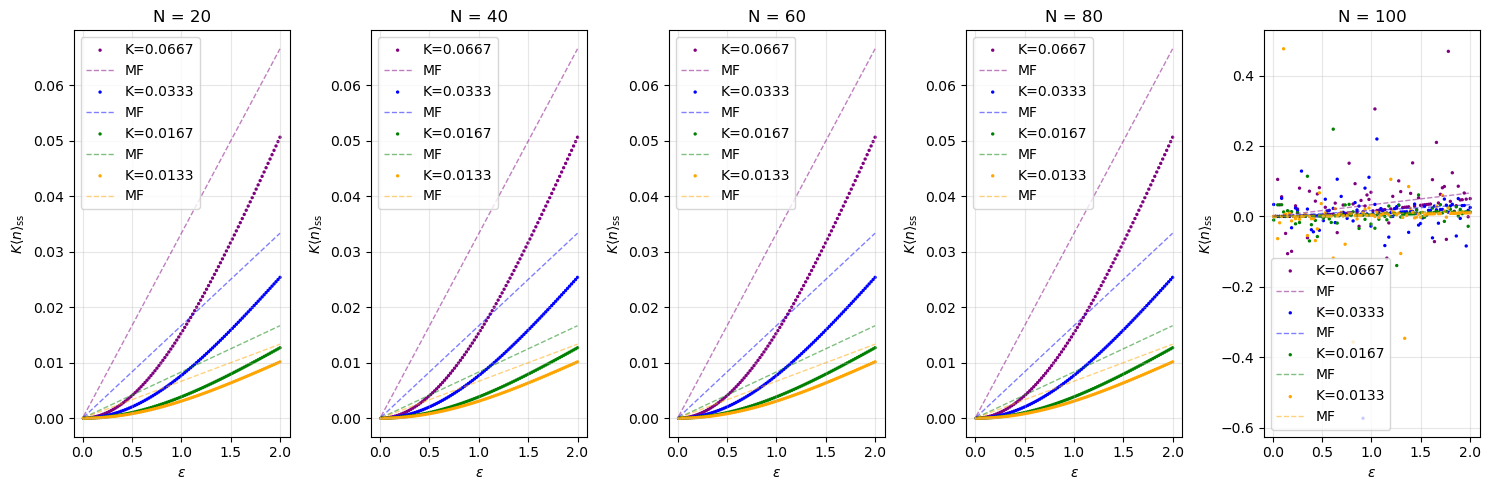

<Figure size 640x480 with 0 Axes>

In [15]:
#---------- Mean Field --------------------------------------
n_mf = []
for k in K_list:
    mf = []
    for e in epsi_list:
        
        r = e**2/(k**2 + g**2)
        n_mfx = 0.5 * np.sqrt(r)
        mf.append(n_mfx) 
    n_mf.append(np.array(mf))  
print(len(n_mf))
#------------------------------------------------------------
"""
Para la grafica en el eje x seria mi epsi_list y el eje y es K*n_1values
"""
fig, axes = plt.subplots(1, len(N), figsize=(15, 5))
colors = ['purple', 'blue', 'green', 'orange']

for idx_d, (ax, d) in enumerate(zip(axes, N)):
    for i, K in enumerate(K_list):
        ax.scatter(epsi_list, K * n_2values[idx_d, i, :], 
                  c=colors[i % len(colors)], s=2, 
                  label=f"K={K:.4f}", ls= '-.'
                  )
        ax.plot(epsi_list, K*n_mf[i], 
                c=colors[i % len(colors)], lw=1, 
                linestyle='--', label='MF', alpha=0.5
               )
        
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$K\langle n\rangle_{\rm ss}$")
    ax.set_title(f"N = {d}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('2photon/n_vs_epsilon_1photon.pdf')
